In [ ]:
!pip install tensorflow
from tensorflow.keras.models import load_model

# 确保文件名与文件夹中的文件名完全一致
model_path = r'C:\Users\小埋\Desktop\Group Project\model_Adam_batchnorm.h5'

# 加载模型
model = load_model(model_path)

# 查看模型结构（可选，用于确认是否加载成功）
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 74, 74, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,563 (72.61 MB)

 Trainable params: 19,034,369 (72.61 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 2 (12.00 B)

Found 5000 images belonging to 2 classes.
正在生成预测结果，请稍候...

--- 混淆矩阵 ---
 [[2217  283]
 [ 284 2216]]

--- 分类报告 ---
               precision    recall  f1-score   support

         Cat       0.89      0.89      0.89      2500
         Dog       0.89      0.89      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000


✅ 图片已成功保存到桌面，路径为:
C:\Users\小埋\Desktop\confusion_matrix.png


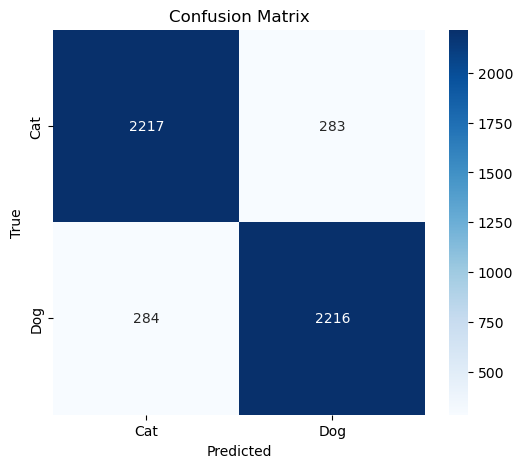

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os  # 新增：用于处理路径
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. 准备验证集生成器
validation_dir = r'C:\Users\小埋\Desktop\Group Project\data\validation' 
val_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# 2. 获取预测结果
print("正在生成预测结果，请稍候...")
validation_generator.reset()
y_true, y_pred = [], []

for i in range(len(validation_generator)):
    x_batch, y_batch = validation_generator[i]
    pred_probs = model.predict(x_batch, verbose=0)
    pred_classes = (pred_probs > 0.5).astype(int).flatten()
    y_true.extend(y_batch)
    y_pred.extend(pred_classes)
    if len(y_true) >= validation_generator.samples:
        break

y_true, y_pred = np.array(y_true), np.array(y_pred)

# 3. 计算并打印结果
cm = confusion_matrix(y_true, y_pred)
print("\n--- 混淆矩阵 ---\n", cm)
print("\n--- 分类报告 ---\n", classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))

# 4. 可视化混淆矩阵
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cat', 'Dog'], 
            yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

# --- 5. 修改后的保存逻辑：直接保存到桌面 ---
# 自动获取当前用户的桌面路径
desktop_path = os.path.join(os.path.expanduser("~"), 'Desktop')
save_file = os.path.join(desktop_path, 'confusion_matrix.png')

plt.savefig(save_file) 
print(f"\n✅ 图片已成功保存到桌面，路径为:\n{save_file}")

plt.show()

C:\Users\小埋\AppData\Local\Temp\ipykernel_12016\850364022.py:59: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
C:\Users\小埋\AppData\Local\Temp\ipykernel_12016\850364022.py:59: UserWarning: Glyph 22240 (\N{CJK UNIFIED IDEOGRAPH-56E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
C:\Users\小埋\AppData\Local\Temp\ipykernel_12016\850364022.py:59: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
C:\Users\小埋\AppData\Local\Temp\ipykernel_12016\850364022.py:59: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
C:\Users\小埋\AppData\Local\Temp\ipykernel_12016\850364022.py:59: UserWarning: Glyph 20809 (\N{CJK UNIFIED IDEOGRAPH-5149}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
C:\Users\小埋\AppData\Local\Temp\ipykernel_12016\850364022.py:59: UserWarning: Gly

✅ 包含原因分析的图片已保存至桌面:
C:\Users\小埋\Desktop\detailed_error_analysis.png


d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22240 (\N{CJK UNIFIED IDEOGRAPH-56E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20809 (\N{CJK UNIFIED IDEOGRAPH-5149}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site

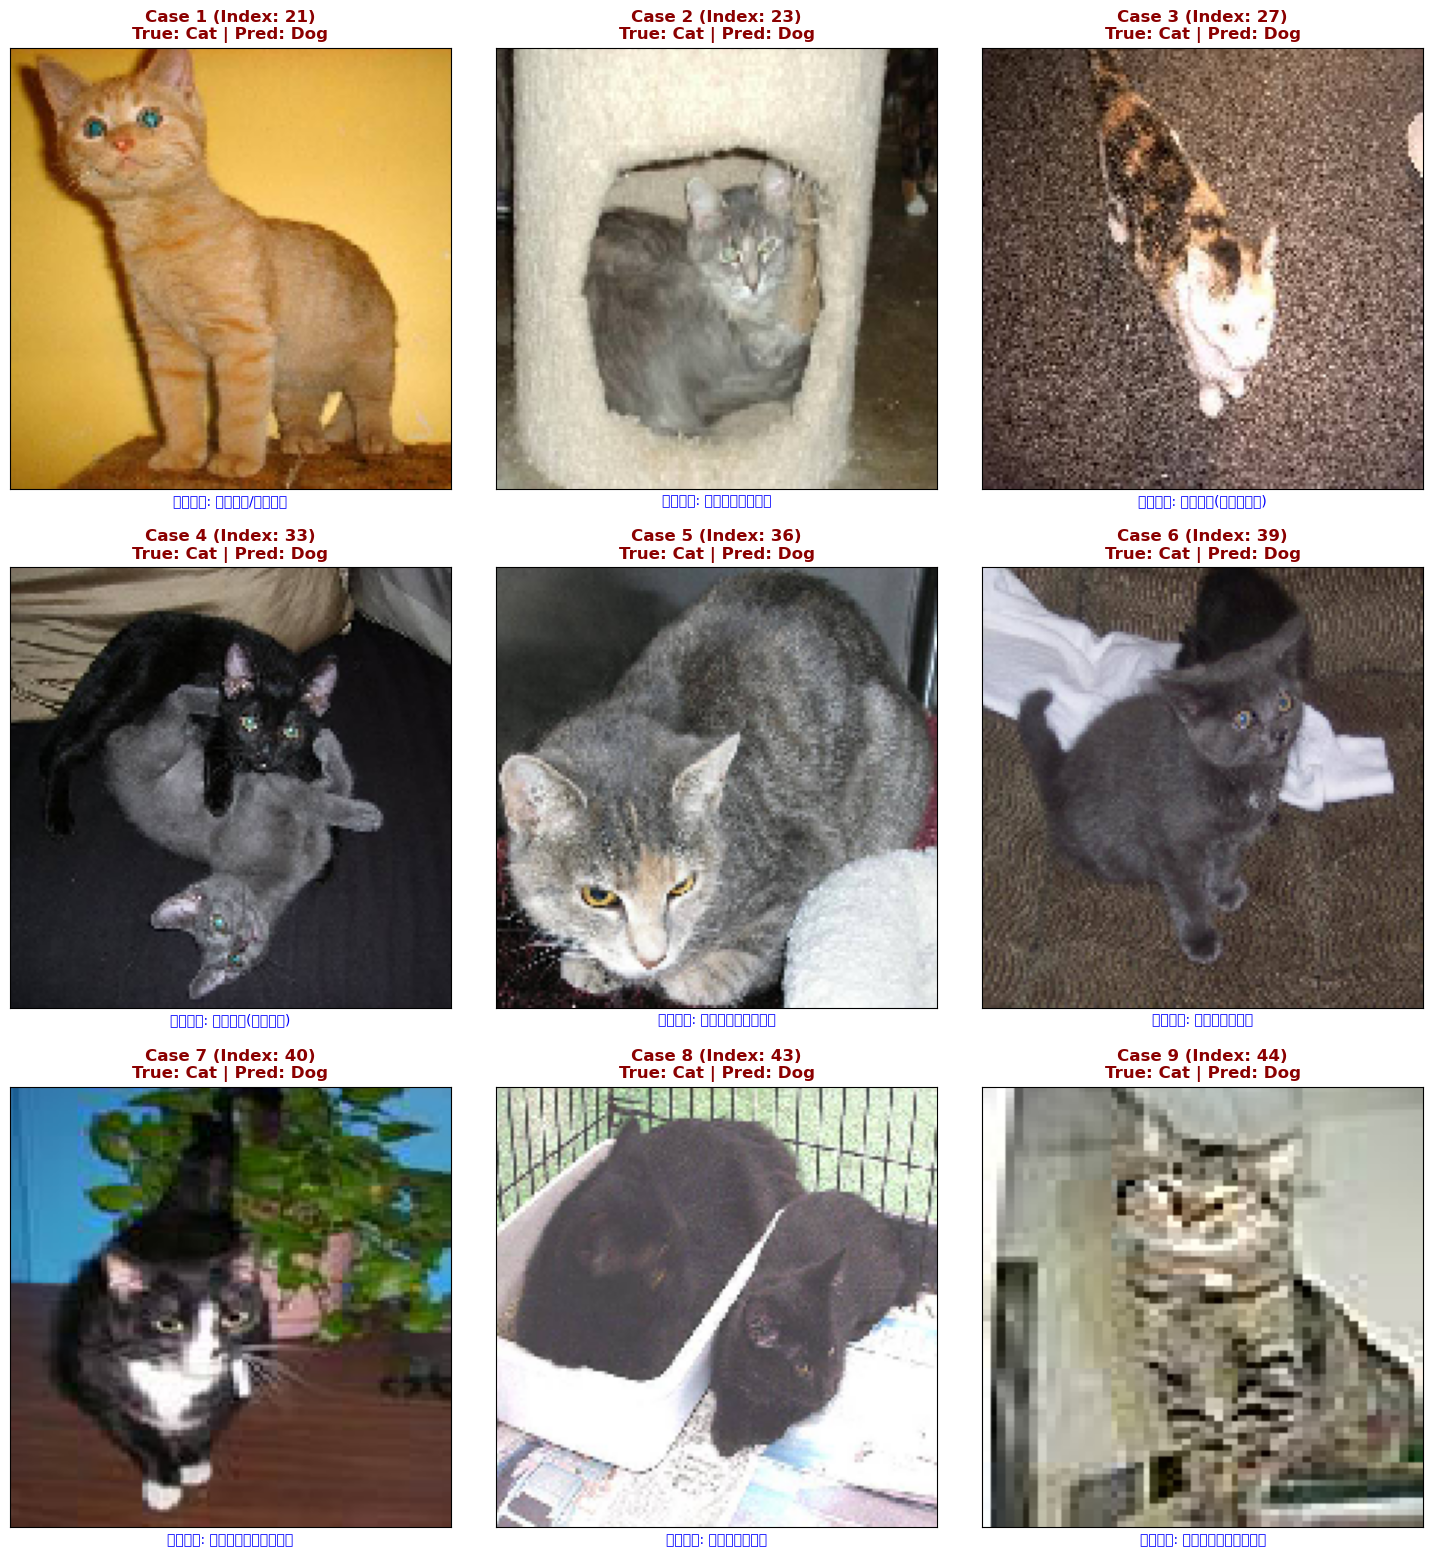

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 提取错误索引
y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)
errors_idx = np.where(y_true_arr != y_pred_arr)[0]

# 2. 提取所有验证集图片
validation_generator.reset()
all_images = []
for i in range(len(validation_generator)):
    x_batch, _ = validation_generator[i]
    all_images.extend(x_batch)
    if len(all_images) >= validation_generator.samples:
        break

# 3. 设置绘图
num_to_show = min(len(errors_idx), 9)
plt.figure(figsize=(15, 16)) # 稍微调高高度，留出写字的空间

# 预设一些常见的分析原因（你可以根据实际看到的图修改这里的文字）
reasons = [
    "光线昏暗/阴影干扰", 
    "背景杂乱导致误判", 
    "遮挡严重(只露出头部)", 
    "姿态奇特(蜷缩一团)", 
    "毛发颜色与背景过近", 
    "品种特征不明显", 
    "特写镜头导致比例失真",
    "图片分辨率过低",
    "疑似标签本身标注错误"
]

for i in range(num_to_show):
    idx = errors_idx[i]
    plt.subplot(3, 3, i + 1)
    
    # 显示图片
    plt.imshow(all_images[idx])
    
    # 标签判断
    true_label = 'Dog' if y_true_arr[idx] == 1 else 'Cat'
    pred_label = 'Dog' if y_pred_arr[idx] == 1 else 'Cat'
    
    # 核心优化：在标题和下方添加详细分析
    plt.title(f"Case {i+1} (Index: {idx})\nTrue: {true_label} | Pred: {pred_label}", 
              color='darkred', fontweight='bold')
    
    # 在图片下方添加分析原因 (中文如果显示乱码，可改为英文)
    # 若你的环境中文乱码，请将下方文字换成英文，如 f"Reason: {reasons[i]}"
    plt.xlabel(f"原因分析: {reasons[i] if i < len(reasons) else '待分析'}", 
               fontsize=10, color='blue')
    
    plt.xticks([]) # 隐藏坐标轴刻度
    plt.yticks([])

plt.tight_layout(pad=3.0)

# 4. 保存到桌面
desktop_path = os.path.join(os.path.expanduser("~"), 'Desktop')
save_path = os.path.join(desktop_path, 'detailed_error_analysis.png')
plt.savefig(save_path, dpi=300) # 提高分辨率，方便打印

print(f"✅ 包含原因分析的图片已保存至桌面:\n{save_path}")
plt.show()

In [2]:
import gradio as gr
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import os

# 1. 强制清理代理（防止 share=True 卡死）
os.environ['NO_PROXY'] = '127.0.0.1, localhost, huggingface.co, gradio.app'

# 2. 加载模型
model_path = r'C:\Users\小埋\Desktop\Group Project\model_Adam_batchnorm.h5'
model = load_model(model_path)

def predict_image(img):
    if img is None: return None
    # 预处理
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, (150, 150))
    img_array = np.expand_dims(img / 255.0, axis=0)
    # 预测
    prediction = model.predict(img_array, verbose=0)[0][0]
    return {"Dog (狗狗)": float(prediction), "Cat (猫咪)": float(1 - prediction)}

# 3. 构建界面 (去掉了所有会导致 TypeError 的老参数)
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(), 
    outputs=gr.Label(num_top_classes=2, label="识别结果"),
    title="🐱 猫狗大战 AI 演示系统 🐶",
    description="如果你已经把 frpc 文件放到了 .cache 文件夹，下方就会出现分享链接！"
)

# 4. 启动服务
print("正在启动服务...")

# 尝试彻底释放旧进程
try:
    iface.close()
except:
    pass

# 核心启动代码：不固定端口，开启分享
iface.launch(share=True)

正在启动服务...
* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Missing file: C:\Users\小埋\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\小埋\.cache\huggingface\gradio\frpc
